# Цель файла

Парсинг переписки, EDA и создание признаков. На выходе — `data/features.csv`.

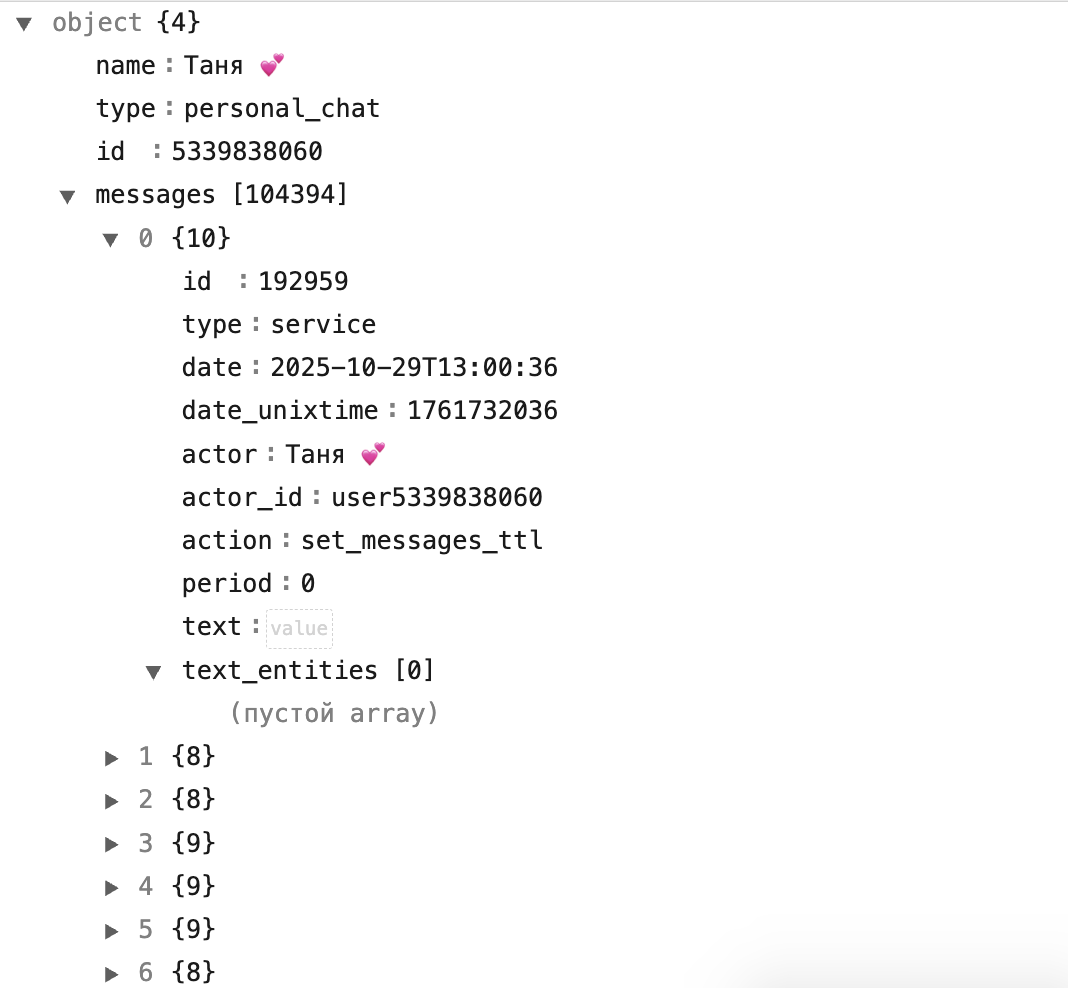

In [1]:
import numpy as np
import json
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import holidays
from astral import LocationInfo
from astral.sun import sun
from datetime import timedelta

# Парсинг

Парсим `chat.json`, достаём время первого утреннего приветствия за каждый день.

In [2]:
def extract_text(raw):
    if isinstance(raw, str):
        return raw
    if isinstance(raw, list):
        parts = []
        for item in raw:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                parts.append(item.get("text", ""))
        return "".join(parts)
    return ""

def is_morning_greeting(text):
    t = text.lower()
    return "добр" in t or "утр" in t


## Парсинг

Фильтр: сообщение содержит «добр» или «утр», отправлено между 05:00 и 14:00. Берём первое такое сообщение за день для каждого участника.


In [3]:
CHAT_PATH = "./data/chat.json"
OUT_PATH = "data/wake_times.csv"

with open(CHAT_PATH, "r") as f:
    data = json.load(f)

rows = []
for m in data["messages"]:
    if m["type"] != "message":
        continue
    text = extract_text(m["text"])
    if not is_morning_greeting(text):
        continue
    dt = datetime.fromisoformat(m["date"])
    hour = dt.hour
    if not (5 <= hour < 14):
        continue
    rows.append({
        "date": dt.date(),
        "person": m["from"],
        "wake_minutes": hour * 60 + dt.minute,
        "datetime": dt,
    })

df = pd.DataFrame(rows)
df = df.sort_values("datetime")
df = df.groupby(["date", "person"], as_index=False).first()
df = df[["date", "person", "wake_minutes"]].sort_values(["person", "date"])

os.makedirs("data", exist_ok=True)
df.to_csv(OUT_PATH, index=False)
df.head(10)

,date,person,wake_minutes
0,2025-10-30,Мансур Зайнуллин,501
2,2025-10-31,Мансур Зайнуллин,684
4,2025-11-01,Мансур Зайнуллин,569
7,2025-11-03,Мансур Зайнуллин,545
9,2025-11-04,Мансур Зайнуллин,665
11,2025-11-05,Мансур Зайнуллин,732
13,2025-11-06,Мансур Зайнуллин,732
15,2025-11-07,Мансур Зайнуллин,810
17,2025-11-08,Мансур Зайнуллин,541
19,2025-11-09,Мансур Зайнуллин,582


## EDA

Смотрим на данные до построения признаков. Числа первичны - графики потом.


In [4]:
df_eda = pd.read_csv("data/wake_times.csv", parse_dates=["date"])
df_eda["day_of_week"] = df_eda["date"].dt.dayofweek
DOW_NAMES = {0: "пн", 1: "вт", 2: "ср", 3: "чт", 4: "пт", 5: "сб", 6: "вс"}


### Числа


In [5]:
df_eda.groupby("person")["wake_minutes"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
person,,,,,,,,
Мансур Зайнуллин,188.0,606.2,86.2,317.0,546.5,607.0,669.2,830.0
Таня 💕,195.0,551.0,74.8,300.0,505.5,550.0,597.5,780.0


In [6]:
dow_mean = (
    df_eda.groupby(["person", "day_of_week"])["wake_minutes"]
    .mean().round(1).reset_index()
)
dow_mean["day_name"] = dow_mean["day_of_week"].map(DOW_NAMES)
dow_mean["time"] = dow_mean["wake_minutes"].apply(lambda m: f"{int(m)//60:02d}:{int(m)%60:02d}")
dow_mean.pivot(index="day_name", columns="person", values="time").reindex(
    ["пн", "вт", "ср", "чт", "пт", "сб", "вс"]
)


person,Мансур Зайнуллин,Таня 💕
day_name,,
пн,09:49,09:13
вт,09:57,09:02
ср,10:15,09:13
чт,10:18,09:12
пт,10:00,09:09
сб,09:33,08:51
вс,10:48,09:31


Я встаю в среднем на 55 минут позже Тани (10:06 против 9:11). Разброс у обоих большой - std ~80 мин, есть что предсказывать.

замечание: суббота у нас обоих раньше среднего (Я 9:33, Таня 8:51). Воскресенье - самый поздний день (Мансур 10:48, Таня 9:31). Паттерн "выходные = поспать" работает только для воскресенья.


### Пропуски


In [7]:
for person, group in df_eda.groupby("person"):
    dates = group["date"].sort_values()
    full_range = pd.date_range(dates.min(), dates.max(), freq="D")
    missing = full_range.difference(dates)
    gaps = []
    for i in range(1, len(missing)):
        if (missing[i] - missing[i-1]).days == 1:
            gaps[-1] += 1 if gaps else None
        else:
            gaps.append(1)
    if not gaps and len(missing) > 0:
        gaps = [1] * len(missing)
    print(f"{person}: {len(missing)} пропущенных дней ({100*len(missing)/len(full_range):.1f}%), макс пробел: {max(gaps) if gaps else 0} дней")


Мансур Зайнуллин: 10 пропущенных дней (5.1%), макс пробел: 1 дней
Таня 💕: 3 пропущенных дней (1.5%), макс пробел: 1 дней


### Распределение времени пробуждения


/var/folders/gg/bml4b3hs12gbbw_sdm078fw40000gn/T/ipykernel_87177/2635470722.py:18: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mansurzainullin/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


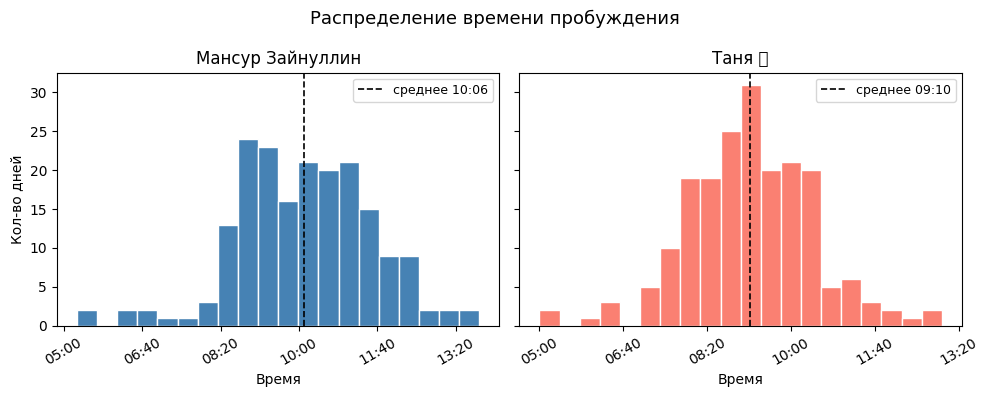

In [8]:
# попробывал применить правило Фридмана-Дьякониса 
# для выбора количества бинов в гистограмме, но получились 
# слшком широкие столбцы, вернулся к bins=20
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (person, color) in zip(axes, [("Мансур Зайнуллин", "steelblue"), ("Таня 💕", "salmon")]):
    data = df_eda[df_eda["person"] == person]["wake_minutes"]
    ax.hist(data, bins=20, color=color, edgecolor="white")
    mean = data.mean()
    ax.axvline(mean, color="black", linestyle="--", linewidth=1.2,
               label=f"среднее {int(mean)//60:02d}:{int(mean)%60:02d}")
    ax.set_title(person)
    ax.set_xlabel("Время")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)//60:02d}:{int(x)%60:02d}"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Кол-во дней")
fig.suptitle("Распределение времени пробуждения", fontsize=13)
plt.tight_layout()
plt.show()

У меня подозрение на бимодальность: два пика около 8:35 и 10:25, скорее всего два режима дня — дни с ранними парами и без. У Тани распределение ближе к нормальному, пик совпадает со средним 9:11. Оба имеют правый хвост — редкие очень поздние пробуждения.

### Паттерн по дням недели


/var/folders/gg/bml4b3hs12gbbw_sdm078fw40000gn/T/ipykernel_87177/3093110891.py:21: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mansurzainullin/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


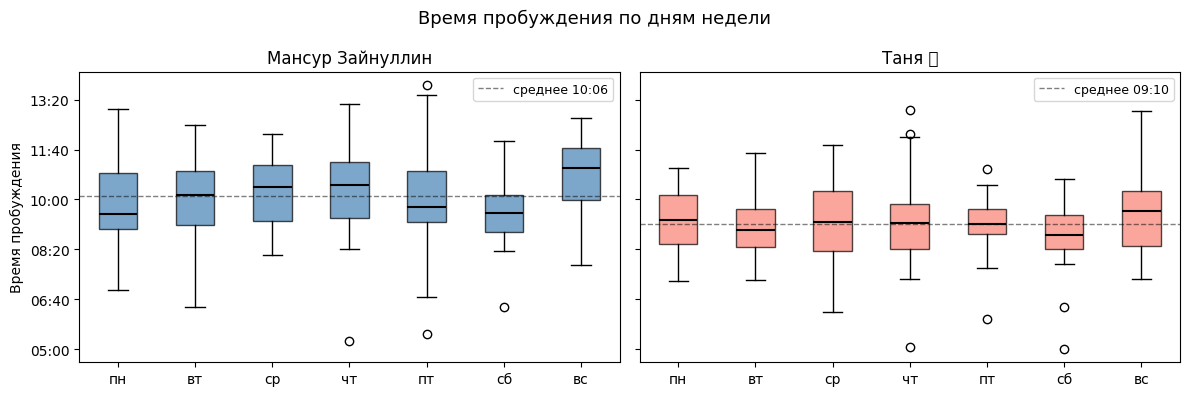

In [9]:
order = ["пн", "вт", "ср", "чт", "пт", "сб", "вс"]
df_eda["day_name"] = df_eda["day_of_week"].map(DOW_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (person, color) in zip(axes, [("Мансур Зайнуллин", "steelblue"), ("Таня 💕", "salmon")]):
    data = df_eda[df_eda["person"] == person]
    groups = [data[data["day_name"] == d]["wake_minutes"].values for d in order]
    bp = ax.boxplot(groups, tick_labels=order, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    gm = data["wake_minutes"].mean()
    ax.axhline(gm, color="black", linestyle="--", linewidth=1, alpha=0.5,
               label=f"среднее {int(gm)//60:02d}:{int(gm)%60:02d}")
    ax.set_title(person)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)//60:02d}:{int(y)%60:02d}"))
    ax.legend(fontsize=9)
axes[0].set_ylabel("Время пробуждения")
fig.suptitle("Время пробуждения по дням недели", fontsize=13)
plt.tight_layout()
plt.show()


Воскресенье — самый поздний день у обоих (я 10:48, Таня 9:31). Суббота раньше среднего (я 9:33, Таня 8:51) — суббота в ВУЗе учебный день, поэтому "выходные = поспать" работает только для воскресенья. У меня разброс по дням сильнее: от 9:33 до 10:48 (75 мин). У Тани стабильнее: 8:51–9:31 (40 мин).

### Корреляция между мной и Таней


Общих дней: 188, корреляция Пирсона: 0.419


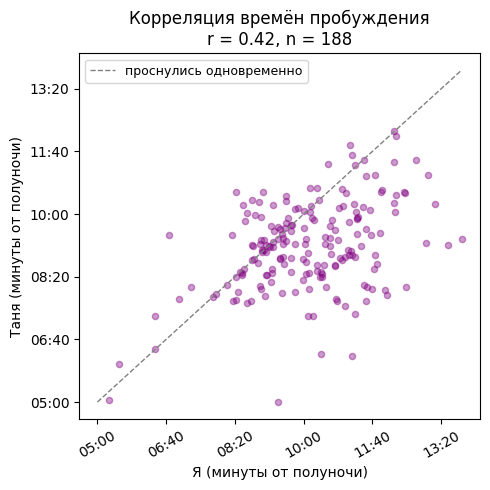

In [10]:
pivot = df_eda.pivot(index="date", columns="person", values="wake_minutes")
pivot.columns = ["mansur", "tanya"]
pivot_clean = pivot.dropna()

corr = pivot_clean.corr().loc["mansur", "tanya"]
print(f"Общих дней: {len(pivot_clean)}, корреляция Пирсона: {corr:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pivot_clean["mansur"], pivot_clean["tanya"], alpha=0.4, color="purple", s=20)

lim_min = min(pivot_clean["mansur"].min(), pivot_clean["tanya"].min())
lim_max = max(pivot_clean["mansur"].max(), pivot_clean["tanya"].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], color="gray", linewidth=1,
        linestyle="--", label="проснулись одновременно")

ax.set_xlabel("Я (минуты от полуночи)")
ax.set_ylabel("Таня (минуты от полуночи)")
ax.set_title(f"Корреляция времён пробуждения\nr = {corr:.2f}, n = {len(pivot_clean)}")
fmt = plt.FuncFormatter(lambda x, _: f"{int(x)//60:02d}:{int(x)%60:02d}")
ax.xaxis.set_major_formatter(fmt)
ax.yaxis.set_major_formatter(fmt)
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


r=0.40 на 189 общих днях. В 70% дней я встаю позже Тани, в 24% — она позже меня. Когда я встаю позже, Таня тоже склонна вставать позже, но связь не сильная — у каждого свой независимый паттерн.

In [11]:
# топ-5 самых ранних и поздних дней для каждого
for person, g in df_eda.groupby("person"):
    print(person)
    print(g.nsmallest(3, "wake_minutes")[["date","wake_minutes"]])
    print(g.nlargest(3, "wake_minutes")[["date","wake_minutes"]])
    print()


Мансур Зайнуллин
         date  wake_minutes
85 2026-01-29           317
86 2026-01-30           331
80 2026-01-24           384
         date  wake_minutes
66 2026-01-09           830
7  2025-11-07           810
53 2025-12-25           791

Таня 💕
          date  wake_minutes
286 2026-02-07           300
277 2026-01-29           304
278 2026-01-30           360
          date  wake_minutes
339 2026-04-02           780
191 2025-11-02           778
195 2025-11-06           732



Замечание: мои экстримальные значения - это новый год :) У Тани тоже такое наблюдается, но меньше

## Feature Engineering

Главное правило: значение признака должно быть известно ДО момента пробуждения, иначе утечка из будущего.

Беру 12 признаков.

Мой собственный режим:
- `lag1_wake` -- во сколько встал вчера, самый прямой сигнал
- `rolling_mean_7` -- среднее за последние 7 дней. Если всю неделю встаю поздно, и сегодня скорее тоже
- `dow_mean_deviation` -- насколько среднее время в этот день недели отклоняется от глобального среднего. Явно кодирует "суббота раньше, воскресенье позже". Считаю отдельно после сплита, иначе утечка

История Тани:
- `other_person_lag1_wake` -- во сколько Таня встала вчера. В EDA корреляция r=0.40, её вчерашнее время несёт сигнал и про моё сегодняшнее

Календарь и природа:
- `day_of_week` -- день недели (0=пн, 6=вс)
- `is_holiday` -- праздник или выходной по календарю РФ (через `holidays`)
- `sunrise_minutes` -- время восхода в Питере (через `astral`). Гипотеза: светлее утром, встаю раньше

Вечерняя активность в чате, косвенные сигналы во сколько лёг:
- `msg_count_prev` -- сколько сообщений написал в окне с 5 утра вчера до 5 утра сегодня
- `last_msg_before_5` -- время последнего сообщения в этом окне
- `goodnight_time` -- время последнего сообщения с "ночи"/"спок" в этом окне

Сон:
- `sleep_duration_prev` -- сколько часов спал прошлой ночью (от goodnight до пробуждения). `lag1_wake` ловит "когда встал", этот признак "сколько спал", разные сигналы, держу оба
- `sleep_duration_rolling_7` -- среднее за 7 ночей. Гипотеза sleep debt: если на этой неделе недосыпал, захочу выспаться

Что отбрасываю:
- `month` и `days_since_start` -- данные за полгода, в конце наблюдений модель видит значения которых не было в начале, при временном сплите это экстраполяция
- `lag2_wake` -- на ~150 точках лишний лаг добавляет шум быстрее чем сигнал
- `has_goodnight` -- пропусков почти нет, признак почти константа
- `day_length_minutes` -- то же что `sunrise_minutes`, та же проблема экстраполяции

Часть из 12 может оказаться слабой, финальный отбор через RFE.

In [12]:
df_feat = pd.read_csv("data/wake_times.csv", parse_dates=["date"])
df_feat = df_feat.sort_values(["person", "date"]).reset_index(drop=True)

df_feat["lag1_wake"] = df_feat.groupby("person")["wake_minutes"].shift(1)
df_feat["day_of_week"] = df_feat["date"].dt.dayofweek
df_feat["rolling_mean_7"] = (
    df_feat.groupby("person")["wake_minutes"]
        .shift(1)
        .rolling(7, min_periods=7)
        .mean()
)

print(f"Shape: {df_feat.shape}")
for col in ["lag1_wake", "day_of_week", "rolling_mean_7"]:
    n_nan = df_feat[col].isna().sum()
    print(f"  {col}: {n_nan} NaN ({100*n_nan/len(df_feat):.1f}%)")

df_feat[df_feat["person"] == "Мансур Зайнуллин"].head(10)[
    ["date", "wake_minutes", "lag1_wake", "day_of_week", "rolling_mean_7"]
]


Shape: (383, 6)
  lag1_wake: 2 NaN (0.5%)
  day_of_week: 0 NaN (0.0%)
  rolling_mean_7: 14 NaN (3.7%)


,date,wake_minutes,lag1_wake,day_of_week,rolling_mean_7
0,2025-10-30,501,NaN,3,NaN
1,2025-10-31,684,501.0,4,NaN
2,2025-11-01,569,684.0,5,NaN
3,2025-11-03,545,569.0,0,NaN
4,2025-11-04,665,545.0,1,NaN
5,2025-11-05,732,665.0,2,NaN
6,2025-11-06,732,732.0,3,NaN
7,2025-11-07,810,732.0,4,632.571429
8,2025-11-08,541,810.0,5,676.714286
9,2025-11-09,582,541.0,6,656.285714


Получил 383 строки. Где NaN — ровно там, где ожидал:
- `lag1_wake` — 2 NaN (по одному первому дню на каждого: у первого дня нет "вчера")
- `day_of_week` — 0 NaN
- `rolling_mean_7` — 14 NaN (по 7 первых дней на каждого: пока не накопилось окно из 7 предыдущих, среднее не посчитать)

Все NaN в начале ряда, никаких сюрпризов внутри. Эти строки потом дропну при сборке финального датасета.

В таблице видна работа `shift`: на 31 октября `lag1_wake = 501` — это `wake_minutes` за 30 октября. `rolling_mean_7` появляется только на 8-й строке (7 ноября) и равно среднему первых 7 дней.


In [13]:
PERSONS = df_feat["person"].unique().tolist()
OTHER = {PERSONS[0]: PERSONS[1], PERSONS[1]: PERSONS[0]}
print(OTHER)

{'Мансур Зайнуллин': 'Таня 💕', 'Таня 💕': 'Мансур Зайнуллин'}


In [14]:
lookup = df_feat.set_index(["date", "person"])["wake_minutes"]

def get_other_lag1(row):
    other = OTHER[row["person"]]
    prev_date = row["date"] - pd.Timedelta(days=1)
    return lookup.get((prev_date, other), float("nan"))

df_feat["other_person_lag1_wake"] = df_feat.apply(get_other_lag1, axis=1)

for person in PERSONS:
    sub = df_feat[df_feat["person"] == person]
    n_nan = sub["other_person_lag1_wake"].isna().sum()
    print(f"  {person}: {n_nan} NaN ({100*n_nan/len(sub):.1f}%)")

print("\nКорреляция lag1_wake vs other_person_lag1_wake:")
for person in PERSONS:
    sub = df_feat[df_feat["person"] == person].dropna(subset=["lag1_wake", "other_person_lag1_wake"])
    r = sub["lag1_wake"].corr(sub["other_person_lag1_wake"])
    print(f"  {person}: r = {r:.3f}")


  Мансур Зайнуллин: 4 NaN (2.1%)
  Таня 💕: 11 NaN (5.6%)

Корреляция lag1_wake vs other_person_lag1_wake:
  Мансур Зайнуллин: r = 0.396
  Таня 💕: r = 0.430


NaN-перекос (Таня 5.6% vs у меня 2.1%) объясняется асимметрией пропусков: у меня 10 дней без утреннего сообщения (5.1% из EDA), у Тани всего 3 (1.5%). Когда Таня хочет узнать "во сколько я встал вчера" — чаще оказывается, что я в тот день вообще не написал "доброе утро" (так как мы проснулись вместе и пожелали друг другу Доброго утра вживую). В обратную сторону — Таня почти всегда есть.

Корреляция `lag1_wake` vs `other_person_lag1_wake` внутри каждого человека ~0.4. Это та же корреляция что я видел в EDA между нашими сегодняшними временами. Низкое значение — хорошо: признаки несут разные сигналы, мультиколлинеарности нет, модель сможет использовать оба.


In [15]:
ru = holidays.Russia()
df_feat["is_holiday"] = df_feat["date"].apply(lambda d: int(d.date() in ru))

n_holidays = df_feat["is_holiday"].sum()
print(f"Праздничных записей: {n_holidays} ({100*n_holidays/len(df_feat):.1f}%)")

print("\nУникальные праздничные даты:")
for d in sorted(df_feat[df_feat["is_holiday"] == 1]["date"].dt.date.unique()):
    print(f"  {d}: {ru.get(d)}")

print("\nСреднее время пробуждения (sanity check, на полном датасете):")
for person in df_feat["person"].unique():
    sub = df_feat[df_feat["person"] == person]
    h_mean = sub[sub["is_holiday"] == 1]["wake_minutes"].mean()
    w_mean = sub[sub["is_holiday"] == 0]["wake_minutes"].mean()
    print(f"  {person}: праздник {h_mean:.0f} мин, обычный {w_mean:.0f} мин, разница {h_mean-w_mean:+.0f}")


Праздничных записей: 27 (7.0%)

Уникальные праздничные даты:
  2025-11-03: Выходной (перенесено с 01.11.2025)
  2025-11-04: День народного единства
  2025-12-31: Выходной (перенесено с 05.01.2025)
  2026-01-01: Новогодние каникулы
  2026-01-02: Новогодние каникулы
  2026-01-04: Новогодние каникулы
  2026-01-05: Новогодние каникулы
  2026-01-06: Новогодние каникулы
  2026-01-07: Рождество Христово
  2026-01-08: Новогодние каникулы
  2026-02-23: День защитника Отечества
  2026-03-08: Международный женский день
  2026-05-01: Праздник Весны и Труда
  2026-05-09: День Победы

Среднее время пробуждения (sanity check, на полном датасете):
  Мансур Зайнуллин: праздник 645 мин, обычный 603 мин, разница +41
  Таня 💕: праздник 549 мин, обычный 551 мин, разница -2


14 уникальных праздничных дат, 27 записей (~7% датасета). `holidays.Russia()` включает перенесённые выходные, например 3 ноября 2025 как перенос с 1 ноября.

У меня в праздники встаю на 41 минуту позже обычного (10:44 vs 10:03). У Тани разница -2 минуты, для неё праздники режим не меняют.

Это ровно тот случай ради которого тренирую две модели отдельно: один и тот же признак может быть сильным для одного человека и бесполезным для другого. В единой модели с переменной "кто" эти противоположные эффекты усреднились бы в шум.

In [16]:
spb = LocationInfo(name="Saint Petersburg", region="Russia", timezone="Europe/Moscow",
                   latitude=59.95, longitude=30.32)

def get_sunrise_minutes(d):
    s = sun(spb.observer, date=d, tzinfo=spb.timezone)
    sr = s["sunrise"]
    return sr.hour * 60 + sr.minute

df_feat["sunrise_minutes"] = df_feat["date"].dt.date.apply(get_sunrise_minutes)

print(f"Диапазон: {df_feat['sunrise_minutes'].min()//60:02d}:{df_feat['sunrise_minutes'].min()%60:02d} — {df_feat['sunrise_minutes'].max()//60:02d}:{df_feat['sunrise_minutes'].max()%60:02d}")
df_feat[["date", "sunrise_minutes"]].drop_duplicates("date").sort_values("date").head(5)


Диапазон: 04:22 — 10:02


,date,sunrise_minutes
0,2025-10-30,496
1,2025-10-31,498
2,2025-11-01,501
191,2025-11-02,503
3,2025-11-03,506


Восход в Питере меняется от 10:02 в декабре до 04:22 в мае. В октябре около 8:16, к маю уже 04:22, признак монотонно убывает к концу датасета.

Чем раньше восход, тем раньше встаю -- проверю через SHAP позже.

Значения в конце датасета (апрель-май, восход 04:22-06:06) не встречаются в начале наблюдений. Для деревьев это экстраполяция за пределы виденного диапазона.

In [17]:
with open("./data/chat.json", "r") as f:
    chat = json.load(f)

msgs = []
for m in chat["messages"]:
    if m["type"] != "message":
        continue
    dt = datetime.fromisoformat(m["date"])
    msgs.append({"person": m["from"], "dt": dt, "text": extract_text(m["text"])})
msgs_df = pd.DataFrame(msgs)

def mins_from_prev_midnight(dt, target_date):
    prev_midnight = datetime.combine(target_date - timedelta(days=1), datetime.min.time())
    return int((dt - prev_midnight).total_seconds() / 60)

In [18]:
rows = []
for _, row in df_feat.iterrows():
    person = row["person"]
    target_date = row["date"].date()
    window_start = datetime.combine(target_date - timedelta(days=1), datetime.min.time()).replace(hour=5)
    window_end = datetime.combine(target_date, datetime.min.time()).replace(hour=5)

    mask = (msgs_df["person"] == person) & (msgs_df["dt"] >= window_start) & (msgs_df["dt"] < window_end)
    window = msgs_df[mask].sort_values("dt")

    msg_count = len(window)
    last_msg = mins_from_prev_midnight(window.iloc[-1]["dt"], target_date) if msg_count > 0 else float("nan")

    gn = window[window["text"].str.lower().str.contains("ночи|спок", na=False)]
    goodnight = mins_from_prev_midnight(gn.iloc[-1]["dt"], target_date) if len(gn) > 0 else float("nan")

    rows.append({
        "date": row["date"],
        "person": person,
        "msg_count_prev": msg_count,
        "last_msg_before_5": last_msg,
        "goodnight_time": goodnight,
    })

df_evening = pd.DataFrame(rows)
df_feat = df_feat.merge(df_evening, on=["date", "person"], how="left")

print(f"Shape: {df_feat.shape}")
for col in ["msg_count_prev", "last_msg_before_5", "goodnight_time"]:
    n = df_feat[col].isna().sum()
    print(f"  {col}: {n} NaN ({100*n/len(df_feat):.1f}%)")


Shape: (383, 12)
  msg_count_prev: 0 NaN (0.0%)
  last_msg_before_5: 0 NaN (0.0%)
  goodnight_time: 20 NaN (5.2%)


У `msg_count_prev` и `last_msg_before_5` — 0 NaN

У `goodnight_time` — 20 NaN (5.2%), это дни без явного "ночи"/"спок"; в этих случаях не угадываю, оставляю NaN.

Время измеряю в минутах от полуночи предыдущего дня. Окно охватывает 24 часа — от 05:00 предыдущего дня до 05:00 текущего:
- `05:00` предыдущего дня = 300 (начало окна)
- `22:00` предыдущего дня = 1320
- `00:00` = 1440
- `04:59` текущего = 1739 (конец окна)

Чем больше число — тем позже сообщение. Шкала остаётся непрерывной при переходе через полночь, линейная модель прочитает её напрямую.

В среднем последнее сообщение в окне — около 23:52 (1432 мин), последнее "ночи" — около 23:25 (1405 мин). 25-й перцентиль `goodnight_time` — 1354 (22:34), то есть ранние "ночи" в окно попадают. Чат активный: 264 сообщения в среднем за вечер, диапазон 2–864.


In [19]:
df_feat["lag1_goodnight"] = df_feat.groupby("person")["goodnight_time"].shift(1)
df_feat["sleep_duration_prev"] = df_feat["lag1_wake"] - df_feat["lag1_goodnight"] + 1440

df_feat["sleep_duration_rolling_7"] = (
    df_feat.groupby("person")["sleep_duration_prev"]
        .shift(1)
        .rolling(7, min_periods=7)
        .mean()
)

for col in ["sleep_duration_prev", "sleep_duration_rolling_7"]:
    n = df_feat[col].isna().sum()
    print(f"  {col}: {n} NaN ({100*n/len(df_feat):.1f}%)")

print("\nСредний сон по людям:")
for person in df_feat["person"].unique():
    sub = df_feat[df_feat["person"] == person]["sleep_duration_prev"].dropna()
    print(f"  {person}: {sub.mean()/60:.1f}h ± {sub.std()/60:.1f}h")

df_feat[df_feat["person"] == "Мансур Зайнуллин"][
    ["date", "lag1_goodnight", "lag1_wake", "sleep_duration_prev", "sleep_duration_rolling_7"]
].head(10)

  sleep_duration_prev: 22 NaN (5.7%)
  sleep_duration_rolling_7: 131 NaN (34.2%)

Средний сон по людям:
  Мансур Зайнуллин: 10.6h ± 2.2h
  Таня 💕: 9.9h ± 2.4h


,date,lag1_goodnight,lag1_wake,sleep_duration_prev,sleep_duration_rolling_7
0,2025-10-30,NaN,NaN,NaN,NaN
1,2025-10-31,1416.0,501.0,525.0,NaN
2,2025-11-01,1419.0,684.0,705.0,NaN
3,2025-11-03,1472.0,569.0,537.0,NaN
4,2025-11-04,1425.0,545.0,560.0,NaN
5,2025-11-05,1493.0,665.0,612.0,NaN
6,2025-11-06,1393.0,732.0,779.0,NaN
7,2025-11-07,1502.0,732.0,670.0,NaN
8,2025-11-08,1400.0,810.0,850.0,626.857143
9,2025-11-09,1480.0,541.0,501.0,673.285714


Считаю `sleep_duration_prev` как `lag1_wake - lag1_goodnight + 1440`. `goodnight_time` для дня N измеряется в минутах от полуночи дня N-2 (диапазон 300-1739), а `wake_minutes` от полуночи дня N-1. Сдвиг опорных точек ровно на сутки, поэтому +1440 даёт корректную разницу независимо от того, ушёл спать до полуночи или после.

Пример: `goodnight=1380` (23:00), `wake=540` (09:00) -> `540 - 1380 + 1440 = 600` мин = 10h.
Пример: `goodnight=1500` (01:00), `wake=540` (09:00) -> `540 - 1500 + 1440 = 480` мин = 8h.

`sleep_duration_rolling_7` -- скользящее среднее за 7 предыдущих ночей, `shift(1)` перед `rolling` чтобы окно не включало позапрошлый сон.

Про название: "длительность сна" -- натяжка. Это время от "спокойной ночи" в чате до утреннего сообщения. У меня ритуал происходит за 1-3 часа до фактического засыпания, пишу Тане "ночи" около 23:00 и ещё работаю. Поэтому средние 10.6h у меня и 9.9h у Тани завышены относительно реального сна (~8h). У Тани смещение меньше.

Поскольку обучаю две отдельные модели, каждая увидит свою смещённую шкалу -- для разделённых моделей это допустимо. В единой модели с переменной "кто" признак работал бы хуже: одно и то же число значило бы разное.

Гипотеза sleep debt работает здесь только косвенно, через ритуал, не через реальный сон. Возможна мультиколлинеарность с `lag1_wake`: если `goodnight_time` стабильно около 23:00, то `sleep_duration_prev` почти линейная функция от `lag1_wake`. Проверю корреляцию в следующем шаге, если высокая -- `sleep_duration_*` отвалится при RFE.

NaN: `sleep_duration_prev` -- 22 (5.7%), первые дни каждого человека плюс дни без "ночи"/"спок". `sleep_duration_rolling_7` -- 131 (34.2%): один пропуск в `goodnight_time` обнуляет следующие 7 окон. Импутирую в следующем шаге.

### Сборка датасета

Собираю все признаки в `data/features.csv`. Дроплю строки где `lag1_wake` пустой — это первые дни каждого человека, для них модель работать не может. Остальные NaN оставляю — что делать уже в Шаге 4.


In [20]:
FEATURE_COLS = [
    "lag1_wake", "day_of_week", "rolling_mean_7",
    "other_person_lag1_wake",
    "is_holiday", "sunrise_minutes",
    "msg_count_prev", "last_msg_before_5", "goodnight_time",
    "sleep_duration_prev", "sleep_duration_rolling_7",
]
KEEP_COLS = ["date", "person", "wake_minutes"] + FEATURE_COLS

df_final = df_feat[df_feat["lag1_wake"].notna()].reset_index(drop=True)
df_final = df_final[KEEP_COLS]

print(f"Shape: {df_final.shape}")
print(f"\nNaN по признакам:")
for col in FEATURE_COLS:
    n = df_final[col].isna().sum()
    print(f"  {col}: {n} ({100*n/len(df_final):.1f}%)")

df_final.to_csv("data/features.csv", index=False)
print(f"\nСохранено: data/features.csv")
df_final.head()


Shape: (381, 14)

NaN по признакам:
  lag1_wake: 0 (0.0%)
  day_of_week: 0 (0.0%)
  rolling_mean_7: 12 (3.1%)
  other_person_lag1_wake: 13 (3.4%)
  is_holiday: 0 (0.0%)
  sunrise_minutes: 0 (0.0%)
  msg_count_prev: 0 (0.0%)
  last_msg_before_5: 0 (0.0%)
  goodnight_time: 20 (5.2%)
  sleep_duration_prev: 20 (5.2%)
  sleep_duration_rolling_7: 129 (33.9%)

Сохранено: data/features.csv


,date,person,wake_minutes,lag1_wake,day_of_week,rolling_mean_7,other_person_lag1_wake,is_holiday,sunrise_minutes,msg_count_prev,last_msg_before_5,goodnight_time,sleep_duration_prev,sleep_duration_rolling_7
0,2025-10-31,Мансур Зайнуллин,684,501.0,4,NaN,500.0,0,498,46,1421,1419.0,525.0,NaN
1,2025-11-01,Мансур Зайнуллин,569,684.0,5,NaN,549.0,0,501,316,1472,1472.0,705.0,NaN
2,2025-11-03,Мансур Зайнуллин,545,569.0,0,NaN,778.0,1,506,283,1569,1425.0,537.0,NaN
3,2025-11-04,Мансур Зайнуллин,665,545.0,1,NaN,540.0,1,509,475,1493,1493.0,560.0,NaN
4,2025-11-05,Мансур Зайнуллин,732,665.0,2,NaN,543.0,0,511,215,1420,1393.0,612.0,NaN


381 строка (-2 от 383 за счёт дропа первого дня каждого человека). 11 признаков плюс `date`, `person`, `wake_minutes`, итого 14 колонок.

NaN:
- 0% -- `lag1_wake`, `day_of_week`, `is_holiday`, `sunrise_minutes`, `msg_count_prev`, `last_msg_before_5`
- 3.1% -- `rolling_mean_7`: первые 6 дней каждого человека
- 3.4% -- `other_person_lag1_wake`: дни когда у партнёра не было утреннего сообщения
- 5.2% -- `goodnight_time` и `sleep_duration_prev`: дни без "ночи"/"спок"
- 33.9% -- `sleep_duration_rolling_7`: один пропуск в `goodnight_time` обнуляет следующие 7 окон

Все NaN либо в начале ряда (накопление окна), либо унаследованы из пропусков. Внутри ряда сюрпризов нет.